[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Intertangler/CB2330-exercises/blob/main/09_end_to_end_modeling/exercise.ipynb)

# Session 09 - End-to-End Modelling

The paper, with abstract copied below, will be the subject of today's exercise. The aim is to, like in the video, walk through steps to build a model based on the published paper. In this case we will guide you through the steps and make the design choices, and your task will be to implement them here.

**Deliverable:** this notebook, run, committed to `cb2330-portfolio`, with figures rendered on the published page.

# Enzymatic RNA synthesis: stepwise yield

Wiegand et al. 2024, *Template-independent enzymatic synthesis of RNA
oligonucleotides*, Nat Biotechnol, doi:10.1038/s41587-024-02244-w. Figure 5c.

Abstract
RNA oligonucleotides have emerged as a powerful therapeutic modality to treat disease, yet current manufacturing methods may not be able to deliver on anticipated future demand. Here, we report the development and optimization of an aqueous-based, template-independent enzymatic RNA oligonucleotide synthesis platform as an alternative to traditional chemical methods. The enzymatic synthesis of RNA oligonucleotides is made possible by controlled incorporation of reversible terminator nucleotides with a common 3′-O-allyl ether blocking group using new CID1 poly(U) polymerase mutant variants. We achieved an average coupling efficiency of 95% and demonstrated ten full cycles of liquid phase synthesis to produce natural and therapeutically relevant modified sequences. We then qualitatively assessed the platform on a solid phase, performing enzymatic synthesis of several N + 5 oligonucleotides on a controlled-pore glass support. Adoption of an aqueous-based process will offer key advantages including the reduction of solvent use and sustainable therapeutic oligonucleotide manufacturing.

---

## About the paper

Wiegand et al. 2024, *Template-independent enzymatic synthesis of RNA oligonucleotides*, Nature Biotechnology, doi:10.1038/s41587-024-02244-w.

RNA oligonucleotides are made today by phosphoramidite chemistry, in organic solvent, and the paper's premise is that an enzyme in water could do the same job. The enzyme is a mutant of CID1 poly(U) polymerase, and the problem with handing a polymerase a pot of nucleotides is that it does not stop at one. So the nucleotide fed to it carries a 3'-O-allyl ether group on its 3' end, which blocks the next addition. The enzyme adds 1 base and then cannot add a second.

A **cycle** is therefore 2 steps and produces exactly 1 base:

1. **Extension.** The polymerase adds 1 blocked nucleotide to the growing chain.
2. **Deblocking.** The allyl group is cut off, which leaves a normal 3' end and makes the chain a substrate again.

Wiegand et al. ran 5 of these cycles on a starting oligonucleotide, which they call N, adding U-U-U-C-G to make an N + 5 product. After each cycle they ran the material on LC/MS and integrated the 260 nm trace to get the **isolated purity**: the fraction of the recovered material that is the chain of the intended length. That is Fig. 5c, and its 6 numbers are the dataset.

2 things to have in mind before reading them.

- The purity at cycle 0 is 0.959 and not 1. The starting material is already not pure, irrespective of the cycles.
- The abstract reports an average coupling efficiency of 95%. This number was measured on its own with mass spectrometry, which will be different from the purity after the multi cycle process.

The paper proposes no model for how the purity falls, so our exercise here is to build such a model.

**[Figure 5, on the paper's own page](https://www.nature.com/articles/s41587-024-02244-w/figures/5)**

Open it beside this notebook. The caption below is for those panels.

### Figure 5. caption
**a**, An N + 5 RNA oligonucleotide with the sequence N + U-U-U-C-G\*, where the asterisk is a 3'-O-allyl ether group. **b**, MALDI-TOF mass spectrometry tracked the extension and deblocking steps of each cycle. **c**, The isolated purity of the growing oligonucleotide was determined after each cycle by LC/MS at 260 nm and 649 nm.

Panel **b** shows the mechanism: Beside each peak indicates the mass of the product which grows as nucleotides are added.

---

# Part A

`math` and `matplotlib` are the imports, and no library does any of the modelling.

In [2]:
import math
import matplotlib.pyplot as plt


## 1. The data

Fig. 5c, transcribed. `purity[n]` is the isolated purity after cycle $n$, a fraction of the recovered material, and `q0` is the purity we started from.

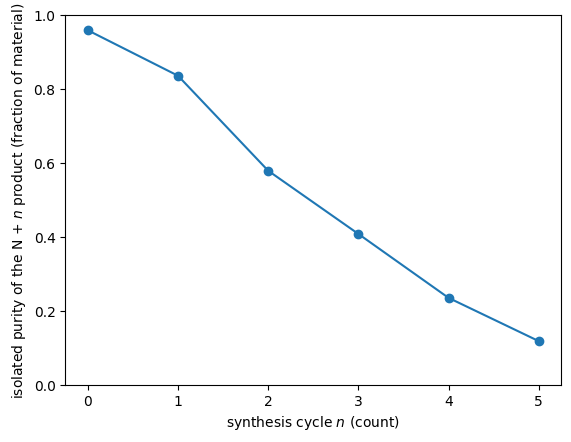

In [3]:
cycle = [0, 1, 2, 3, 4, 5]
purity = [0.959, 0.836, 0.579, 0.408, 0.235, 0.118]
q0 = purity[0]

plt.plot(cycle, purity, "o-")
plt.xlabel("synthesis cycle $n$ (count)")
plt.ylabel("isolated purity of the N + $n$ product (fraction of material)")
plt.ylim(0, 1)
plt.show()


## 2. The random number generator

The same linear congruential generator the course has used throughout. `uniforms(k, seed)` returns `k` numbers on $[0, 1)$, drawn once so that nothing downstream reseeds.

In [4]:
A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out


def position_of_min(values):
    """The position of the smallest value in the list."""
    best = 0
    for i in range(len(values)):
        if values[i] < values[best]:
            best = i
    return best


## 3. Simulating without formula

The mechanism can be described as follows: a molecule sits in the pot through 5 cycles, and on each cycle the polymerase either extends it or does not, with the same probability $p$ every time. Nothing removes a molecule that missed, and nothing gives it a second chance within the cycle, so a molecule that misses once is 1 base short at the end and stays short.

`simulate` takes the number of cycles, the probability $p$, and how many molecules to follow, and returns the length each molecule reached. The uniforms are drawn up front, 1 per molecule per cycle, so `rs[i * n_cycles + c]` is molecule `i`'s draw on cycle `c`.

Here we aim to build a simulation of the oligonucleotide growing mechanism without any formula. The idea will be to follow a molecule through cycles, and on each cycle 1 uniform random number will be used to decide if the molecule should extend. The output will be the length of each molecule. The fraction of them that reached 5 gives us the predicted purity at $p$.

**Fill the gap to write the simulation.** `rs` and `lengths` are set up and `lengths` is returned. Follow each molecule through the cycles, count the cycles it extended on, and record that count as its length. A molecule extends on a cycle when its uniform for that cycle is below `p`.

In [19]:
def simulate(n_cycles, p, n_molecules=10000, seed=8):
    """The length reached by each of n_molecules molecules after n_cycles couplings, each succeeding with probability p."""
    rs = uniforms(n_molecules * n_cycles, seed)
    lengths = [0] * n_molecules
    # ⭐⭐⭐ Your code here ⭐⭐⭐

    for i in range(n_molecules):
      for c in range (n_cycles):
        if rs[i * n_cycles + c] < p:
          lengths[i] = lengths[i] + 1
        else:
          break

    return lengths


lengths = simulate(5, 0.74)
full_length = sum(1 for length in lengths if length == 5) / len(lengths)

In [20]:
assert len(lengths) == 10000, "1 length per molecule"
assert max(lengths) == 5 and min(lengths) >= 0, "a molecule gains between 0 and 5 bases in 5 cycles"
assert 0.20 < full_length < 0.25, "near 0.74 ** 5 = 0.222"
print("ok  full-length fraction after 5 cycles at p = 0.74:", round(full_length, 4), "  against 0.74 ** 5 =", round(0.74 ** 5, 4))


ok  full-length fraction after 5 cycles at p = 0.74: 0.2263   against 0.74 ** 5 = 0.2219


The molecules that are not full length did not disappear. They are still in the pot, 1 or 2 or 3 bases short, and they are the smaller peaks in the paper's MALDI traces.

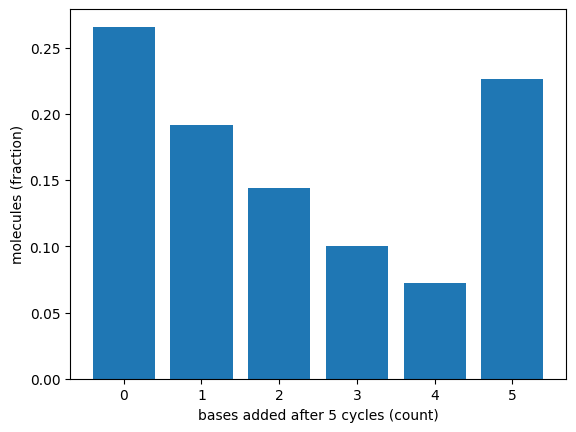

In [21]:
counts = [0] * 6
for length in lengths:
    counts[length] = counts[length] + 1
fractions = [c / len(lengths) for c in counts]

plt.bar(range(6), fractions)
plt.xlabel("bases added after 5 cycles (count)")
plt.ylabel("molecules (fraction)")
plt.show()


## 4. Proposed probabilistic model

$$q(n) = q_0 \, p^{\,n}$$

The simulation gives us a synthetic output, so a formula is not needed to produce such a result. But the formula will allow us to perform fitting to data. A molecule is full length after $n$ cycles when it extended on cycle 1 and on cycle 2 and so on to cycle $n$, which is $p$ multiplied by itself $n$ times, and $q_0$ is the fraction that was the right length before we started.

This cell runs the simulation at each cycle count and draws $p^{\,n}$ over it.

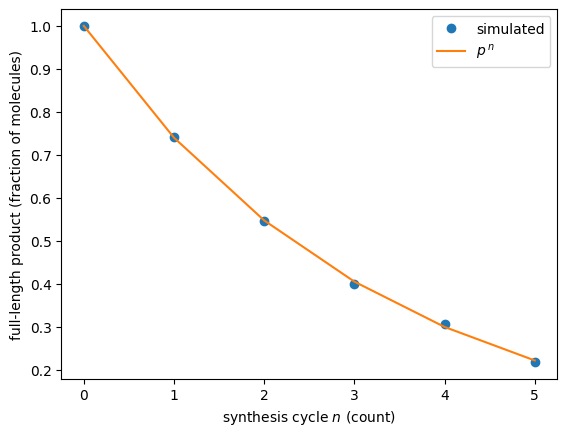

In [22]:
def yield_model(n, p, q0=q0):
    """The fraction of material still full length after n cycles at a per-cycle efficiency p."""
    return q0 * p ** n


p_test = 0.74
sim = []
for n in cycle:
    lengths_n = simulate(n, p_test, seed=8 + n) if n > 0 else [0] * 10000
    sim.append(sum(1 for length in lengths_n if length == n) / len(lengths_n))

plt.plot(cycle, sim, "o", label="simulated")
plt.plot(cycle, [yield_model(n, p_test) / q0 for n in cycle], "-", label="$p^{\\,n}$")
plt.xlabel("synthesis cycle $n$ (count)")
plt.ylabel("full-length product (fraction of molecules)")
plt.legend()
plt.show()


## 5. Likelihood and fitting

$$p(x \mid p) = \prod_{n=0}^{5} \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left[-\frac{(x_n - q_0 p^{\,n})^2}{2\sigma^2}\right], \qquad \mathrm{NLL}(p) = -\sum_{n=0}^{5} \ln \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left[-\frac{(x_n - q_0 p^{\,n})^2}{2\sigma^2}\right]$$

The measured purity $x_n$ misses the model's prediction $q_0 p^{\,n}$ by some amount, and to score a candidate $p$ we need a claim about how large a miss is ordinary. The claim here is a Gaussian of width $\sigma = 0.02$, 2 percentage points, which is roughly what integrating an LC/MS peak is worth. It is assumed and not measured, and section 7 shows what rides on it.

`gaussian` and `position_of_min` are written, and `grid` holds 451 candidate efficiencies from 0.500 to 0.950, a step of 0.001 apart. The grid stops short of the ends because a candidate far from the data gives a density that underflows to 0, and its logarithm does not exist.

Write functions to score the likelihood of candidate efficiency parameters against the 6 measurements from the paper. The likelihood is the probability the measurements would have come out as they did if $p$ were the truth, and its logarithm negated because 6 densities multiplied together produce a small number.

Using the score, we can scan candidate parameters and identify the best of those tested.

**Fill the 3 gaps to score the candidates and fit $p$.** Write `likelihood` as the product over the cycles of `gaussian` at the measured purity, with the model's prediction as the mean and `SIGMA` as the width. Write `nll` as the same quantity turned into a sum: minus the log of that density, accumulated over the cycles. Then fill `scores`, 1 score per candidate in `grid`; `position_of_min` takes it from there.

In [40]:
SIGMA = 0.02                                      # the assumed measurement scale on a purity, in fraction of material


def gaussian(x, mu, sigma):
    """The Gaussian density at x, for a mean mu and a standard deviation sigma."""
    return math.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / (sigma * math.sqrt(2 * math.pi))


def likelihood(p):
    """p(data | p): the product over the cycles of the Gaussian density at each measured purity."""
    # ⭐⭐⭐ Your code here ⭐⭐⭐
    product = 1
    for n in cycle:
      product = product * gaussian(purity[n], yield_model(n, p), SIGMA)
    return product

    pass


def nll(p):
    """Minus the log of the likelihood: the same score written as a sum, which stays in a readable range."""
    # ⭐⭐⭐ Your code here ⭐⭐
    score = 0
    for n in cycle:
      score = score - math.log(gaussian(purity[n], yield_model(n, p), SIGMA))
    return score

grid = [0.5 + 0.001 * i for i in range(451)]
scores = [0.0] * len(grid)
# ⭐⭐⭐ Your code here ⭐⭐⭐
for j in range(len(grid)):
  scores[j] = nll(grid[j])

p_hat = grid[position_of_min(scores)]


In [41]:
assert abs(nll(0.74) + math.log(likelihood(0.74))) < 1e-9, "the 2 scores are the same score"
assert 0.72 < p_hat < 0.76, "the efficiency the 6 purities prefer"
print("ok  p_hat", round(p_hat, 3), "  NLL at p_hat", round(nll(p_hat), 2), "  likelihood at p_hat", format(likelihood(p_hat), ".3e"))


ok  p_hat 0.741   NLL at p_hat 20.77   likelihood at p_hat 9.581e-10


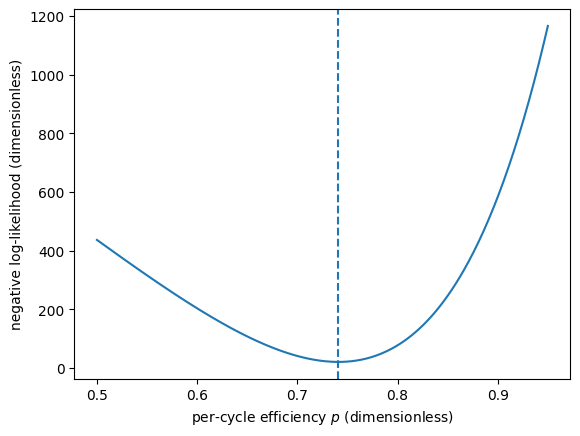

In [42]:
plt.plot(grid, scores)
plt.axvline(p_hat, ls="--")
plt.xlabel("per-cycle efficiency $p$ (dimensionless)")
plt.ylabel("negative log-likelihood (dimensionless)")
plt.show()


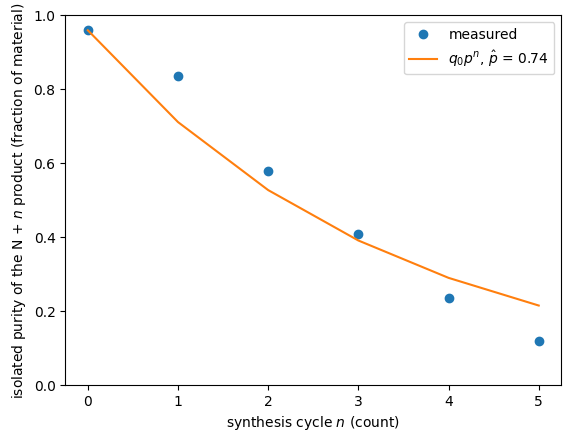

In [43]:
plt.plot(cycle, purity, "o", label="measured")
plt.plot(cycle, [yield_model(n, p_hat) for n in cycle], "-",
         label=f"$q_0 p^n$, $\\hat p$ = {p_hat:.2f}")
plt.xlabel("synthesis cycle $n$ (count)")
plt.ylabel("isolated purity of the N + $n$ product (fraction of material)")
plt.ylim(0, 1)
plt.legend()
plt.show()


## 6. Residuals

The fitted curve passes through the data at a glance, and the residual is what a glance misses. This cell draws the measured purity minus the predicted one, cycle by cycle.

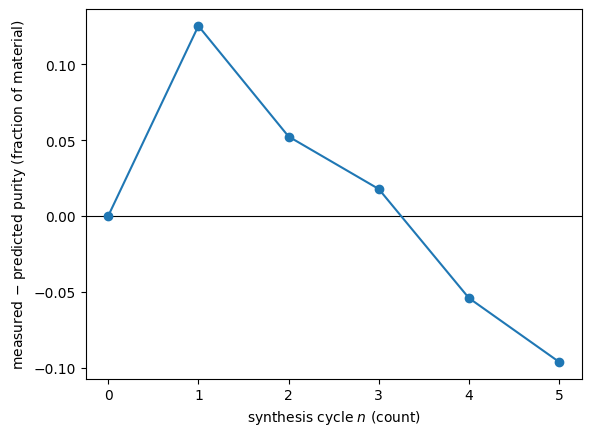

residuals: [0.0, 0.125, 0.052, 0.018, -0.054, -0.096]


In [44]:
resid = [purity[n] - yield_model(n, p_hat) for n in cycle]

plt.axhline(0, color="k", lw=0.8)
plt.plot(cycle, resid, "o-")
plt.xlabel("synthesis cycle $n$ (count)")
plt.ylabel("measured $-$ predicted purity (fraction of material)")
plt.show()

print("residuals:", [round(r, 3) for r in resid])


The residuals run positive, positive, positive, negative, negative: an arc, not a scatter. A model whose misses take turns in sign has the shape of the data wrong, and the size of the misses is beside the point. Sections 7 and 8 are 2 replies to that, and they reply to different halves of it.

## 7. The error bar on $\hat{p}$, from the curvature

$$\sigma_{\hat{p}} = \frac{1}{\sqrt{\mathrm{NLL}''(\hat{p})}}, \qquad \mathrm{NLL}''(\hat{p}) \approx \frac{\mathrm{NLL}(\hat{p} + h) - 2\,\mathrm{NLL}(\hat{p}) + \mathrm{NLL}(\hat{p} - h)}{h^2}$$

In order to understand how much we can trust our parameter estimate, we will characterize the curvature. A score that bends sharply at its minimum rules out the candidates either side of $\hat{p}$; a score with less curvature leaves those candidates as viable options. The curvature is measured with the second derivative, and 3 evaluations of the score, at the minimum and a step $h$ either side, measure it. `h` is set at 0.01.

The aim is a width to report beside $\hat{p}$, taken from how sharply the score bends at its minimum. 3 evaluations are enough, and the arithmetic that turns them into a width is 2 lines.

**Fill the gap to compute the error bar.** `h` is set at 0.01. Write `curvature` as the second difference of `nll` at $\hat{p}$, and `se_p` as 1 over its square root.

In [45]:
h = 0.01
# ⭐⭐⭐ Your code here ⭐⭐⭐
curvature = (nll(p_hat+h) - 2*nll(p_hat)+nll(p_hat - h))/(h**2)
se_p = 1/((nll(p_hat+h) - 2*nll(p_hat)+nll(p_hat - h))/(h**2)**0.5)


In [46]:
assert curvature > 0, "a minimum curves upwards"
assert 0.003 < se_p < 0.012, "a few parts in a thousand on the efficiency"
print("ok  p_hat", round(p_hat, 3), "+/-", round(se_p, 4), "  curvature", round(curvature, 1))


ok  p_hat 0.741 +/- 0.0037   curvature 27208.4


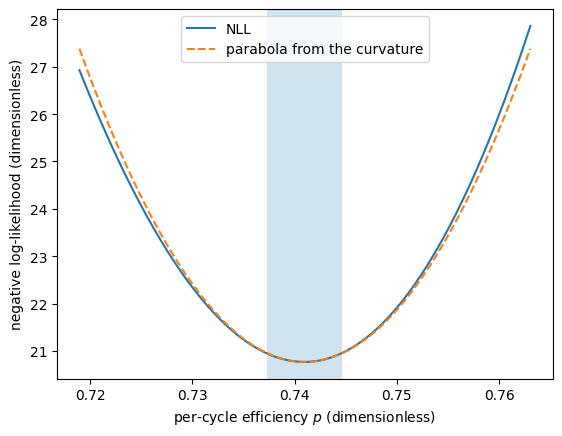

In [47]:
near = [p_hat - 6 * se_p + 12 * se_p * i / 200 for i in range(201)]

plt.plot(near, [nll(p) for p in near], label="NLL")
plt.plot(near, [nll(p_hat) + 0.5 * curvature * (p - p_hat) ** 2 for p in near], "--",
         label="parabola from the curvature")
plt.axvspan(p_hat - se_p, p_hat + se_p, alpha=0.2)
plt.xlabel("per-cycle efficiency $p$ (dimensionless)")
plt.ylabel("negative log-likelihood (dimensionless)")
plt.legend()
plt.show()


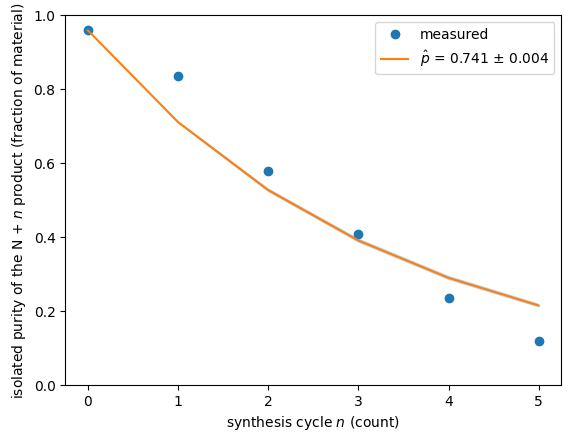

In [48]:
low = [yield_model(n, p_hat - se_p) for n in cycle]
high = [yield_model(n, p_hat + se_p) for n in cycle]

plt.plot(cycle, purity, "o", label="measured")
plt.plot(cycle, [yield_model(n, p_hat) for n in cycle], "-",
         label=f"$\\hat p$ = {p_hat:.3f} $\\pm$ {se_p:.3f}")
plt.fill_between(cycle, low, high, alpha=0.3)
plt.xlabel("synthesis cycle $n$ (count)")
plt.ylabel("isolated purity of the N + $n$ product (fraction of material)")
plt.ylim(0, 1)
plt.legend()
plt.show()


The band is thinner than the marker and the measured points sit outside it, which is section 6's arc restated in a second place. The width of a fit answers how well the data pin down $p$ if the model is right, and says nothing about whether it is.

The width also carries $\sigma$ with it. NLL is the squared misses over $2\sigma^2$, so halving the assumed measurement scale quarters the curvature and doubles the error bar, and I picked 0.02 rather than measuring it. There are no replicates in Fig. 5c to measure it from.

## 8. A decaying efficiency

$$q(n) = q_0 \prod_{k=0}^{n-1} p \lambda^{k}$$

The other half of section 6's arc is the shape, and this is the smallest change that alters it: let the efficiency itself fall as the chain grows, by a factor $\lambda$ per cycle, so cycle $k$ couples at $p\lambda^{k}$ instead of $p$. At $\lambda = 1$ this is section 4's model, so the constant-$p$ fit is a candidate inside this one. A longer chain folding on itself and hiding its 3' end is one mechanism that would do this, and the data cannot tell us it is that one.

This section is written, and it is here to be read rather than filled. The cell scores a 201 by 201 grid of the 2 parameters on the same NLL as section 5, over a range narrow enough that the density does not underflow, and the figures are the score surface and the 2 fitted curves over the data.

In [49]:
def yield_model2(n, p, lam, q0=q0):
    """The fraction still full length after n cycles when cycle k couples at p * lam ** k."""
    q = q0
    for k in range(n):
        q = q * p * lam ** k
    return q


def nll2(p, lam):
    """Section 5's score, for the 2-parameter model."""
    score = 0.0
    for n in cycle:
        score = score - math.log(gaussian(purity[n], yield_model2(n, p, lam), SIGMA))
    return score


ps = [0.70 + 0.00125 * i for i in range(201)]    # 0.700 to 0.950
lams = [0.80 + 0.001 * i for i in range(201)]    # 0.800 to 1.000
surface = [[nll2(p, lam) for p in ps] for lam in lams]

best = min(min(row) for row in surface)
for i, row in enumerate(surface):
    if best in row:
        lam_hat, p2_hat = lams[i], ps[row.index(best)]

print("p_hat", round(p2_hat, 4), " lam_hat", round(lam_hat, 4), " NLL", round(best, 2),
      " against NLL", round(nll(p_hat), 2), "for the constant-p model")


p_hat 0.8475  lam_hat 0.881  NLL -16.2  against NLL 20.77 for the constant-p model


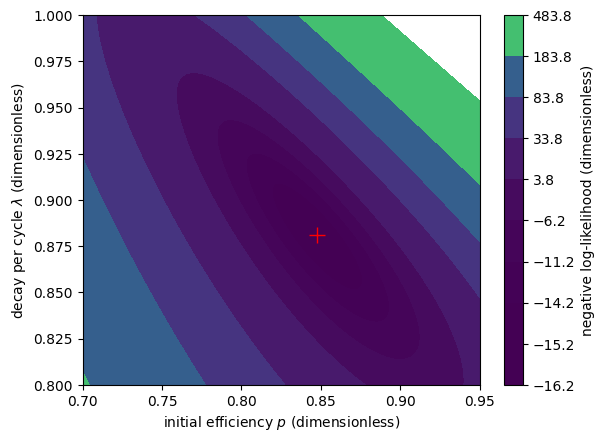

In [50]:
plt.contourf(ps, lams, surface, levels=[best + d for d in (0, 1, 2, 5, 10, 20, 50, 100, 200, 500)])
plt.plot(p2_hat, lam_hat, "r+", ms=12)
plt.xlabel("initial efficiency $p$ (dimensionless)")
plt.ylabel("decay per cycle $\\lambda$ (dimensionless)")
plt.colorbar(label="negative log-likelihood (dimensionless)")
plt.show()


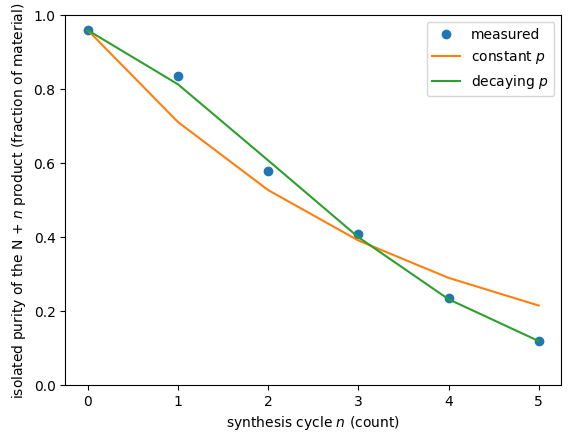

In [51]:
plt.plot(cycle, purity, "o", label="measured")
plt.plot(cycle, [yield_model(n, p_hat) for n in cycle], "-", label="constant $p$")
plt.plot(cycle, [yield_model2(n, p2_hat, lam_hat) for n in cycle], "-", label="decaying $p$")
plt.xlabel("synthesis cycle $n$ (count)")
plt.ylabel("isolated purity of the N + $n$ product (fraction of material)")
plt.ylim(0, 1)
plt.legend()
plt.show()


1 extra parameter takes about 37 off the score and flattens the arc, and it also takes the fitted first-cycle efficiency from 0.74 up to 0.85. Neither number is the paper's 95%, and neither is wrong: the abstract's 95% is the extension step assayed alone, and ours is a whole cycle, extension and deblocking and the material lost in handling it. The gap between the 2 is a quantity the paper does not report, and reading it off took a model.

---

# Part B

Part B is optional and done outside the session, and a route is enough.

- **The bootstrap on 6 points.** Resample the 6 cycles with replacement, refit $p$ on each resample, and take the spread of the estimates. Set it beside section 7's 0.006. The 2 measure different things here, because a resample of 6 points sometimes drops the cycles that carry the curve.
- **A 95% interval in place of an error bar.** Section 5's `scores` already hold the whole curve, so the candidates within 1.92 of the minimum are a 95% likelihood interval. 1.92 is $\tfrac12 z^2$ at $z = 1.96$, and $\tfrac12$ would give the 68% version, which is section 7's error bar reached by walking rather than by differentiating.
- **What $\sigma$ is worth.** Rerun sections 5 and 7 at $\sigma = 0.01$ and $\sigma = 0.04$. $\hat{p}$ does not move and the error bar scales with $\sigma$, which locates the assumption: it sets the width, not the estimate.
- **The fit in log space.** $\ln q = \ln q_0 + n \ln p$ is a straight line in $n$, so the 6 points can be fitted by a least-squares line through logs with no grid at all. The estimate differs from section 5's, because a Gaussian on the purity and a Gaussian on its log are 2 different claims about the measurement.